# DriftGuard — Structured Machine-Learning Models

This notebook trains structured machine-learning classifiers using engineered
features derived directly from configuration changes.

The models use characteristics such as:

- Field-path depth and composition
- Old and new value lengths and data types
- Numeric and textual value patterns
- File extension and directory structure
- Configuration type
- Parser mode
- Change operation
- Commit-message characteristics

The following are deliberately excluded:

- Weak labels and label confidence
- Security-rule identifiers
- Weak-label explanations
- Repository identity
- Commit hashes
- Validation and test repositories

Models are trained on the temporal model-training partition and evaluated on
the commit-disjoint temporal development partition.

In [1]:
import os
import sys
import json
import math
import re
import time
import warnings
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    log_loss,
    classification_report,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
from tqdm import tqdm


print("=" * 72)
print("DRIFTGUARD — STRUCTURED MACHINE-LEARNING MODELS")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"
BASELINE_OUTPUT_DIR = (
    PROJECT_ROOT / "outputs" / "baseline_models"
)

MODELS_DIR = (
    PROJECT_ROOT / "models" / "structured"
)

OUTPUTS_DIR = (
    PROJECT_ROOT / "outputs" / "structured_models"
)

TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
FEATURES_DIR = OUTPUTS_DIR / "features"
CONFIGS_DIR = PROJECT_ROOT / "configs"

for directory in [
    MODELS_DIR,
    OUTPUTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    FEATURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

warnings.filterwarnings(
    "default",
    category=ConvergenceWarning,
)

print("Python version     :", sys.version.split()[0])
print("Scikit-learn      :", sklearn.__version__)
print("Python executable :", sys.executable)
print("Conda environment :", os.environ.get("CONDA_DEFAULT_ENV", "Not detected"))
print("Project root      :", PROJECT_ROOT)
print("Models directory  :", MODELS_DIR)
print("Outputs directory :", OUTPUTS_DIR)

DRIFTGUARD — STRUCTURED MACHINE-LEARNING MODELS
Python version     : 3.11.15
Scikit-learn      : 1.9.0
Python executable : C:\Users\Lenovo\anaconda3\envs\driftguard\python.exe
Conda environment : driftguard
Project root      : C:\Users\Lenovo\Desktop\DriftGuard
Models directory  : C:\Users\Lenovo\Desktop\DriftGuard\models\structured
Outputs directory : C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models


In [2]:
STRUCTURED_SETTINGS = {
    "random_seed": 42,

    "class_order": [
        "benign",
        "low",
        "medium",
        "high",
        "critical",
    ],

    "one_hot_minimum_frequency": 5,
    "one_hot_maximum_categories": 100,

    "maximum_value_processing_length": 4_000,
    "maximum_path_processing_length": 2_000,
    "maximum_commit_message_length": 2_000,

    "permutation_importance_repeats": 5,
    "permutation_importance_top_n": 30,

    "minimum_configuration_group_size": 10,

    "selection_metrics": [
        "macro_f1",
        "critical_recall",
        "high_critical_recall",
        "balanced_accuracy",
    ],
}

CLASS_ORDER = STRUCTURED_SETTINGS[
    "class_order"
]

structured_settings_path = (
    CONFIGS_DIR
    / "structured_model_training_settings.json"
)

with structured_settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        STRUCTURED_SETTINGS,
        file,
        indent=2,
    )

print(
    json.dumps(
        STRUCTURED_SETTINGS,
        indent=2,
    )
)

print(
    "\nSaved settings to:",
    structured_settings_path,
)

{
  "random_seed": 42,
  "class_order": [
    "benign",
    "low",
    "medium",
    "high",
    "critical"
  ],
  "one_hot_minimum_frequency": 5,
  "one_hot_maximum_categories": 100,
  "maximum_value_processing_length": 4000,
  "maximum_path_processing_length": 2000,
  "maximum_commit_message_length": 2000,
  "permutation_importance_repeats": 5,
  "permutation_importance_top_n": 30,
  "minimum_configuration_group_size": 10,
  "selection_metrics": [
    "macro_f1",
    "critical_recall",
    "high_critical_recall",
    "balanced_accuracy"
  ]
}

Saved settings to: C:\Users\Lenovo\Desktop\DriftGuard\configs\structured_model_training_settings.json


In [3]:
model_training_path = (
    CLEAN_DATA_DIR
    / "train_temporal_model_train.csv.gz"
)

temporal_development_path = (
    CLEAN_DATA_DIR
    / "train_temporal_development.csv.gz"
)

if not model_training_path.exists():
    raise FileNotFoundError(
        f"Missing training dataset:\n{model_training_path}"
    )

if not temporal_development_path.exists():
    raise FileNotFoundError(
        "Missing temporal-development dataset:\n"
        f"{temporal_development_path}"
    )

model_training_data = pd.read_csv(
    model_training_path,
    compression="gzip",
    low_memory=False,
)

temporal_development_data = pd.read_csv(
    temporal_development_path,
    compression="gzip",
    low_memory=False,
)

print(
    "Model-training records:",
    f"{len(model_training_data):,}",
)

print(
    "Temporal-development records:",
    f"{len(temporal_development_data):,}",
)

print(
    "Training repositories:",
    sorted(
        model_training_data[
            "repository"
        ].unique()
    ),
)

Model-training records: 7,711
Temporal-development records: 1,865
Training repositories: ['kube_prometheus', 'microservices_demo', 'terraform_aws_vpc']


In [4]:
baseline_comparison_path = (
    BASELINE_OUTPUT_DIR
    / "tables"
    / "baseline_model_comparison.csv"
)

baseline_results = pd.DataFrame()
best_baseline_row = None

if baseline_comparison_path.exists():
    baseline_results = pd.read_csv(
        baseline_comparison_path
    )

    baseline_results = baseline_results.sort_values(
        [
            "macro_f1",
            "critical_recall",
            "high_critical_recall",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    ).reset_index(drop=True)

    best_baseline_row = baseline_results.iloc[0]

    print(
        "Best Notebook 07 baseline:",
        best_baseline_row["model"],
    )

    print(
        "Baseline macro F1:",
        f"{best_baseline_row['macro_f1']:.4f}",
    )

    print(
        "Baseline critical recall:",
        f"{best_baseline_row['critical_recall']:.4f}",
    )

else:
    print(
        "Notebook 07 comparison file was not found."
    )

Best Notebook 07 baseline: hybrid_linear_svm
Baseline macro F1: 0.8991
Baseline critical recall: 0.8125


In [5]:
REQUIRED_COLUMNS = [
    "diff_id",
    "repository",
    "commit_hash",
    "commit_author_date",
    "commit_message",
    "file_path",
    "configuration_type",
    "parser_mode",
    "operation",
    "field_path",
    "old_value",
    "new_value",
    "training_target",
    "sample_weight",
    "temporal_partition",
]

missing_training_columns = sorted(
    set(REQUIRED_COLUMNS)
    - set(model_training_data.columns)
)

missing_development_columns = sorted(
    set(REQUIRED_COLUMNS)
    - set(temporal_development_data.columns)
)

if missing_training_columns:
    raise ValueError(
        "Training data is missing columns:\n"
        + "\n".join(
            missing_training_columns
        )
    )

if missing_development_columns:
    raise ValueError(
        "Development data is missing columns:\n"
        + "\n".join(
            missing_development_columns
        )
    )

print("Required-column validation: PASSED")

Required-column validation: PASSED


In [7]:
for dataframe in [
    model_training_data,
    temporal_development_data,
]:
    dataframe["training_target"] = (
        dataframe["training_target"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    dataframe["sample_weight"] = pd.to_numeric(
        dataframe["sample_weight"],
        errors="coerce",
    )

    dataframe["commit_author_datetime"] = pd.to_datetime(
        dataframe["commit_author_date"],
        errors="coerce",
        utc=True,
    )

invalid_training_labels = (
    ~model_training_data[
        "training_target"
    ].isin(CLASS_ORDER)
)

invalid_development_labels = (
    ~temporal_development_data[
        "training_target"
    ].isin(CLASS_ORDER)
)

if invalid_training_labels.any():
    raise ValueError(
        "Invalid training labels were found."
    )

if invalid_development_labels.any():
    raise ValueError(
        "Invalid development labels were found."
    )

if model_training_data[
    "sample_weight"
].isna().any():
    raise ValueError(
        "Training sample weights contain missing values."
    )

if (
    model_training_data[
        "sample_weight"
    ] <= 0
).any():
    raise ValueError(
        "Training sample weights must be positive."
    )

training_commit_keys = set(
    zip(
        model_training_data["repository"],
        model_training_data["commit_hash"],
    )
)

development_commit_keys = set(
    zip(
        temporal_development_data[
            "repository"
        ],
        temporal_development_data[
            "commit_hash"
        ],
    )
)

overlapping_commit_keys = (
    training_commit_keys
    & development_commit_keys
)

print(
    "Training commits:",
    f"{len(training_commit_keys):,}",
)

print(
    "Development commits:",
    f"{len(development_commit_keys):,}",
)

print(
    "Commit overlap:",
    f"{len(overlapping_commit_keys):,}",
)

if overlapping_commit_keys:
    raise ValueError(
        "Temporal commit leakage detected."
    )

print("Datatype and temporal split validation: PASSED")

Training commits: 1,058
Development commits: 266
Commit overlap: 0
Datatype and temporal split validation: PASSED


In [10]:
FORBIDDEN_FEATURE_COLUMNS = {
    "repository",
    "dataset_split",
    "commit_hash",
    "commit_author_date",
    "commit_author_datetime",
    "diff_id",
    "source_record_id",
    "change_signature_sha256",

    "weak_label",
    "weak_label_confidence",
    "severity_rank",
    "primary_rule_id",
    "matched_rule_ids",
    "matched_rule_count",
    "rule_conflict",
    "weak_label_reason",
    "label_source",
    "label_usage",
    "sensitive_terms",
    "sensitive_term_count",
    "needs_manual_review",

    "training_label_source",
    "training_target",
    "class_weight",
    "label_reliability_weight",
    "parser_reliability_weight",
    "conflict_reliability_weight",
    "sample_weight",
    "temporal_partition",
}

RAW_ALLOWED_COLUMNS = [
    "field_path",
    "old_value",
    "new_value",
    "configuration_type",
    "parser_mode",
    "operation",
    "file_path",
    "commit_message",
]

forbidden_raw_overlap = (
    set(RAW_ALLOWED_COLUMNS)
    & FORBIDDEN_FEATURE_COLUMNS
)

print(
    "Allowed raw columns:",
    RAW_ALLOWED_COLUMNS,
)

print(
    "Forbidden-column overlap:",
    forbidden_raw_overlap,
)

if forbidden_raw_overlap:
    raise ValueError(
        "A forbidden leakage column was selected."
    )

print("Leakage-column validation: PASSED")

Allowed raw columns: ['field_path', 'old_value', 'new_value', 'configuration_type', 'parser_mode', 'operation', 'file_path', 'commit_message']
Forbidden-column overlap: set()
Leakage-column validation: PASSED


In [11]:
def normalize_text_series(
    series,
    maximum_length,
):
    normalized = (
        series
        .fillna("")
        .astype(str)
        .str.replace(
            "\r",
            " ",
            regex=False,
        )
        .str.replace(
            "\n",
            " ",
            regex=False,
        )
        .str.replace(
            "\t",
            " ",
            regex=False,
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
        .str.strip()
    )

    return normalized.str.slice(
        0,
        maximum_length,
    )


def character_entropy(value):
    text = str(value)

    if not text:
        return 0.0

    counts = Counter(text)
    length = len(text)

    entropy = 0.0

    for count in counts.values():
        probability = count / length
        entropy -= (
            probability
            * math.log2(probability)
        )

    return float(entropy)


def infer_value_type(value):
    if value is None:
        return "missing"

    text = str(value).strip()

    if not text:
        return "empty"

    lowered = text.lower()

    if lowered in {
        "null",
        "none",
        "nil",
        "~",
        "<missing>",
    }:
        return "null_like"

    if lowered in {
        "true",
        "false",
        "yes",
        "no",
        "on",
        "off",
    }:
        return "boolean"

    if re.fullmatch(
        r"[-+]?\d+",
        text,
    ):
        return "integer"

    if re.fullmatch(
        r"[-+]?(?:\d+\.\d*|\d*\.\d+)",
        text,
    ):
        return "float"

    if re.fullmatch(
        r"(?:\d{1,3}\.){3}\d{1,3}",
        text,
    ):
        return "ipv4"

    if re.fullmatch(
        r"(?:\d{1,3}\.){3}\d{1,3}/\d{1,2}",
        text,
    ):
        return "cidr"

    if re.match(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        text,
    ):
        return "url"

    if (
        text.startswith("{")
        and text.endswith("}")
    ):
        return "object_like"

    if (
        text.startswith("[")
        and text.endswith("]")
    ):
        return "list_like"

    if (
        "{{" in text
        or "${" in text
        or "<%" in text
    ):
        return "template"

    return "string"


print("Feature helper functions loaded.")

Feature helper functions loaded.


In [13]:
def extract_file_extension(file_path):
    text = str(file_path).strip().lower()

    if not text:
        return "<missing>"

    filename = (
        text.replace("\\", "/")
        .split("/")[-1]
    )

    if filename == "dockerfile":
        return "dockerfile"

    if filename.startswith(
        "dockerfile."
    ):
        return "dockerfile"

    if "." not in filename:
        return "<no_extension>"

    return filename.rsplit(".", 1)[-1]


def extract_top_level_directory(file_path):
    text = (
        str(file_path)
        .strip()
        .replace("\\", "/")
    )

    segments = [
        segment
        for segment in text.split("/")
        if segment
        and segment != "."
    ]

    if not segments:
        return "<root>"

    if len(segments) == 1:
        return "<root>"

    return segments[0].lower()


def extract_field_root(field_path):
    text = str(field_path).strip()

    if not text:
        return "<missing>"

    root = re.split(
        r"[.\[]",
        text,
        maxsplit=1,
    )[0]

    return root.lower() or "<missing>"


def extract_field_leaf(field_path):
    text = str(field_path).strip()

    if not text:
        return "<missing>"

    normalized = re.sub(
        r"\[\d+\]",
        "",
        text,
    )

    segments = [
        segment
        for segment in normalized.split(".")
        if segment
    ]

    if not segments:
        return "<missing>"

    return segments[-1].lower()


print("Path extraction helpers loaded.")

Path extraction helpers loaded.


In [14]:
SECURITY_KEYWORD_PATTERN = (
    r"(?:auth|password|passwd|secret|token|credential|"
    r"certificate|cert|private_key|public_key|permission|"
    r"role|rbac|security|encrypt|decrypt|tls|ssl)"
)

NETWORK_KEYWORD_PATTERN = (
    r"(?:port|host|hostname|address|ip|cidr|network|"
    r"ingress|egress|protocol|firewall|acl|listen|bind|"
    r"route|subnet|gateway|dns)"
)

RESOURCE_KEYWORD_PATTERN = (
    r"(?:cpu|memory|limit|limits|request|requests|quota|"
    r"replica|replicas|storage|timeout|capacity)"
)

EXPOSURE_KEYWORD_PATTERN = (
    r"(?:public|external|expose|exposed|allow|allowed|"
    r"anonymous|wildcard|world|internet)"
)

COMMIT_SECURITY_PATTERN = (
    r"(?:security|secure|vulnerability|cve|auth|"
    r"credential|password|tls|ssl|permission)"
)

COMMIT_REMOVAL_PATTERN = (
    r"(?:remove|removed|delete|deleted|drop|disable|disabled)"
)

COMMIT_FIX_PATTERN = (
    r"(?:fix|fixed|patch|repair|correct|resolve|resolved)"
)


def engineer_structured_features(
    dataframe,
):
    features = pd.DataFrame(
        index=dataframe.index
    )

    field_path = normalize_text_series(
        dataframe["field_path"],
        STRUCTURED_SETTINGS[
            "maximum_path_processing_length"
        ],
    )

    old_value = normalize_text_series(
        dataframe["old_value"],
        STRUCTURED_SETTINGS[
            "maximum_value_processing_length"
        ],
    )

    new_value = normalize_text_series(
        dataframe["new_value"],
        STRUCTURED_SETTINGS[
            "maximum_value_processing_length"
        ],
    )

    file_path = normalize_text_series(
        dataframe["file_path"],
        STRUCTURED_SETTINGS[
            "maximum_path_processing_length"
        ],
    )

    commit_message = normalize_text_series(
        dataframe["commit_message"],
        STRUCTURED_SETTINGS[
            "maximum_commit_message_length"
        ],
    )

    field_lower = field_path.str.lower()
    old_lower = old_value.str.lower()
    new_lower = new_value.str.lower()
    file_lower = file_path.str.lower()
    commit_lower = commit_message.str.lower()

    # Categorical features
    features["configuration_type"] = (
        dataframe["configuration_type"]
        .fillna("<missing>")
        .astype(str)
        .str.lower()
    )

    features["parser_mode"] = (
        dataframe["parser_mode"]
        .fillna("<missing>")
        .astype(str)
        .str.lower()
    )

    features["operation"] = (
        dataframe["operation"]
        .fillna("<missing>")
        .astype(str)
        .str.lower()
    )

    features["file_extension"] = (
        file_path.apply(
            extract_file_extension
        )
    )

    features["top_level_directory"] = (
        file_path.apply(
            extract_top_level_directory
        )
    )

    features["field_root"] = (
        field_path.apply(
            extract_field_root
        )
    )

    features["field_leaf"] = (
        field_path.apply(
            extract_field_leaf
        )
    )

    features["old_value_type"] = (
        old_value.apply(
            infer_value_type
        )
    )

    features["new_value_type"] = (
        new_value.apply(
            infer_value_type
        )
    )

    features["value_type_transition"] = (
        features["old_value_type"]
        + "_to_"
        + features["new_value_type"]
    )

    old_missing = old_value.eq("")
    new_missing = new_value.eq("")

    features["presence_transition"] = np.select(
        [
            old_missing & ~new_missing,
            ~old_missing & new_missing,
            old_missing & new_missing,
        ],
        [
            "missing_to_present",
            "present_to_missing",
            "missing_to_missing",
        ],
        default="present_to_present",
    )

    # Field-path numeric features
    features["field_path_length"] = (
        field_path.str.len()
    )

    features["field_path_depth"] = (
        field_path.str.count(r"\.")
        + field_path.str.count(r"\[")
    )

    features["field_segment_count"] = (
        field_path.str.count(r"\.")
        + 1
    )

    features["field_array_index_count"] = (
        field_path.str.count(
            r"\[\d+\]"
        )
    )

    features["field_digit_count"] = (
        field_path.str.count(r"\d")
    )

    features["field_underscore_count"] = (
        field_path.str.count("_")
    )

    features["field_dash_count"] = (
        field_path.str.count("-")
    )

    features["field_security_keyword_count"] = (
        field_lower.str.count(
            SECURITY_KEYWORD_PATTERN
        )
    )

    features["field_network_keyword_count"] = (
        field_lower.str.count(
            NETWORK_KEYWORD_PATTERN
        )
    )

    features["field_resource_keyword_count"] = (
        field_lower.str.count(
            RESOURCE_KEYWORD_PATTERN
        )
    )

    features["field_exposure_keyword_count"] = (
        field_lower.str.count(
            EXPOSURE_KEYWORD_PATTERN
        )
    )

    # Value lengths
    features["old_value_length"] = (
        old_value.str.len()
    )

    features["new_value_length"] = (
        new_value.str.len()
    )

    features["value_length_change"] = (
        features["new_value_length"]
        - features["old_value_length"]
    )

    features["absolute_value_length_change"] = (
        features[
            "value_length_change"
        ].abs()
    )

    features["old_token_count"] = (
        old_value.str.count(r"\S+")
    )

    features["new_token_count"] = (
        new_value.str.count(r"\S+")
    )

    features["old_line_count"] = (
        old_value.str.count(r"\n")
        + 1
    )

    features["new_line_count"] = (
        new_value.str.count(r"\n")
        + 1
    )

    features["old_digit_count"] = (
        old_value.str.count(r"\d")
    )

    features["new_digit_count"] = (
        new_value.str.count(r"\d")
    )

    features["old_alpha_count"] = (
        old_value.str.count(
            r"[A-Za-z]"
        )
    )

    features["new_alpha_count"] = (
        new_value.str.count(
            r"[A-Za-z]"
        )
    )

    features["old_special_count"] = (
        old_value.str.count(
            r"[^A-Za-z0-9\s]"
        )
    )

    features["new_special_count"] = (
        new_value.str.count(
            r"[^A-Za-z0-9\s]"
        )
    )

    features["old_special_ratio"] = (
        features["old_special_count"]
        / features[
            "old_value_length"
        ].clip(lower=1)
    )

    features["new_special_ratio"] = (
        features["new_special_count"]
        / features[
            "new_value_length"
        ].clip(lower=1)
    )

    features["old_character_entropy"] = (
        old_value.apply(
            character_entropy
        )
    )

    features["new_character_entropy"] = (
        new_value.apply(
            character_entropy
        )
    )

    features["entropy_change"] = (
        features[
            "new_character_entropy"
        ]
        - features[
            "old_character_entropy"
        ]
    )

    features["values_equal"] = (
        old_value.eq(new_value)
    ).astype(int)

    features["old_missing"] = (
        old_missing.astype(int)
    )

    features["new_missing"] = (
        new_missing.astype(int)
    )

    # Generic value-pattern indicators
    ipv4_pattern = (
        r"(?:\b\d{1,3}\.){3}\d{1,3}\b"
    )

    cidr_pattern = (
        r"(?:\b\d{1,3}\.){3}\d{1,3}/\d{1,2}\b"
    )

    url_pattern = (
        r"[A-Za-z][A-Za-z0-9+.-]*://"
    )

    template_pattern = (
        r"(?:\{\{|\$\{|<%)"
    )

    environment_pattern = (
        r"(?:\$\{?[A-Za-z_][A-Za-z0-9_]*\}?)"
    )

    wildcard_pattern = (
        r"(?:\*|0\.0\.0\.0|::/0)"
    )

    for prefix, text_series in [
        ("old", old_lower),
        ("new", new_lower),
    ]:
        features[
            f"{prefix}_contains_ipv4"
        ] = (
            text_series.str.contains(
                ipv4_pattern,
                regex=True,
                na=False,
            )
            .astype(int)
        )

        features[
            f"{prefix}_contains_cidr"
        ] = (
            text_series.str.contains(
                cidr_pattern,
                regex=True,
                na=False,
            )
            .astype(int)
        )

        features[
            f"{prefix}_contains_url"
        ] = (
            text_series.str.contains(
                url_pattern,
                regex=True,
                na=False,
            )
            .astype(int)
        )

        features[
            f"{prefix}_contains_template"
        ] = (
            text_series.str.contains(
                template_pattern,
                regex=True,
                na=False,
            )
            .astype(int)
        )

        features[
            f"{prefix}_contains_environment_reference"
        ] = (
            text_series.str.contains(
                environment_pattern,
                regex=True,
                na=False,
            )
            .astype(int)
        )

        features[
            f"{prefix}_contains_wildcard"
        ] = (
            text_series.str.contains(
                wildcard_pattern,
                regex=True,
                na=False,
            )
            .astype(int)
        )

        features[
            f"{prefix}_security_keyword_count"
        ] = (
            text_series.str.count(
                SECURITY_KEYWORD_PATTERN
            )
        )

        features[
            f"{prefix}_network_keyword_count"
        ] = (
            text_series.str.count(
                NETWORK_KEYWORD_PATTERN
            )
        )

        features[
            f"{prefix}_resource_keyword_count"
        ] = (
            text_series.str.count(
                RESOURCE_KEYWORD_PATTERN
            )
        )

        features[
            f"{prefix}_exposure_keyword_count"
        ] = (
            text_series.str.count(
                EXPOSURE_KEYWORD_PATTERN
            )
        )

    old_numeric = pd.to_numeric(
        old_value,
        errors="coerce",
    )

    new_numeric = pd.to_numeric(
        new_value,
        errors="coerce",
    )

    features["old_is_numeric"] = (
        old_numeric.notna().astype(int)
    )

    features["new_is_numeric"] = (
        new_numeric.notna().astype(int)
    )

    features["old_numeric_log_abs"] = np.log1p(
        old_numeric.abs()
    )

    features["new_numeric_log_abs"] = np.log1p(
        new_numeric.abs()
    )

    features["numeric_change"] = (
        new_numeric - old_numeric
    )

    features["numeric_absolute_change"] = (
        features["numeric_change"].abs()
    )

    # File-path features
    normalized_file_path = (
        file_path
        .str.replace(
            "\\",
            "/",
            regex=False,
        )
    )

    features["file_path_length"] = (
        normalized_file_path.str.len()
    )

    features["file_path_depth"] = (
        normalized_file_path.str.count("/")
    )

    features["file_hidden_component_count"] = (
        normalized_file_path.str.count(
            r"(?:^|/)\."
        )
    )

    features["file_test_path_flag"] = (
        file_lower.str.contains(
            r"(?:^|/)(?:test|tests|testing)(?:/|$)",
            regex=True,
            na=False,
        )
        .astype(int)
    )

    features["file_example_path_flag"] = (
        file_lower.str.contains(
            r"(?:example|examples|sample|samples|demo)",
            regex=True,
            na=False,
        )
        .astype(int)
    )

    features["file_deployment_path_flag"] = (
        file_lower.str.contains(
            r"(?:deploy|deployment|infra|infrastructure|"
            r"kubernetes|k8s|terraform|ansible|helm)",
            regex=True,
            na=False,
        )
        .astype(int)
    )

    # Commit-message features
    features["commit_message_length"] = (
        commit_message.str.len()
    )

    features["commit_message_token_count"] = (
        commit_message.str.count(
            r"\S+"
        )
    )

    features["commit_security_keyword_count"] = (
        commit_lower.str.count(
            COMMIT_SECURITY_PATTERN
        )
    )

    features["commit_removal_keyword_count"] = (
        commit_lower.str.count(
            COMMIT_REMOVAL_PATTERN
        )
    )

    features["commit_fix_keyword_count"] = (
        commit_lower.str.count(
            COMMIT_FIX_PATTERN
        )
    )

    features["commit_revert_flag"] = (
        commit_lower.str.contains(
            r"\brevert(?:ed|ing)?\b",
            regex=True,
            na=False,
        )
        .astype(int)
    )

    features["commit_update_flag"] = (
        commit_lower.str.contains(
            r"\b(?:update|updated|upgrade|bump)\b",
            regex=True,
            na=False,
        )
        .astype(int)
    )

    features.replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
        inplace=True,
    )

    return features


print("Structured feature-engineering function loaded.")

Structured feature-engineering function loaded.


In [15]:
feature_start_time = time.perf_counter()

X_train_structured = (
    engineer_structured_features(
        model_training_data
    )
)

X_development_structured = (
    engineer_structured_features(
        temporal_development_data
    )
)

feature_generation_seconds = (
    time.perf_counter()
    - feature_start_time
)

y_train = (
    model_training_data[
        "training_target"
    ]
    .astype(str)
    .to_numpy()
)

y_development = (
    temporal_development_data[
        "training_target"
    ]
    .astype(str)
    .to_numpy()
)

training_sample_weights = (
    model_training_data[
        "sample_weight"
    ]
    .astype(float)
    .to_numpy()
)

print(
    "Feature generation seconds:",
    f"{feature_generation_seconds:.2f}",
)

print(
    "Training feature shape:",
    X_train_structured.shape,
)

print(
    "Development feature shape:",
    X_development_structured.shape,
)

display(
    X_train_structured.head()
)

Feature generation seconds: 1.28
Training feature shape: (7711, 83)
Development feature shape: (1865, 83)


,configuration_type,parser_mode,operation,file_extension,top_level_directory,field_root,field_leaf,old_value_type,new_value_type,value_type_transition,...,file_test_path_flag,file_example_path_flag,file_deployment_path_flag,commit_message_length,commit_message_token_count,commit_security_keyword_count,commit_removal_keyword_count,commit_fix_keyword_count,commit_revert_flag,commit_update_flag
0,yaml,structured,added,yaml,manifests,$,description,empty,string,empty_to_string,...,0,0,0,37,5,0,0,0,0,1
1,kubernetes,structured,deleted,yaml,release,$,name,string,empty,string_to_empty,...,0,0,1,21,3,0,0,0,0,0
2,kustomize,structured,deleted,yaml,kustomize,$,name,string,empty,string_to_empty,...,0,0,1,22,3,0,0,0,0,0
3,kustomize,structured,modified,yaml,<root>,$,resources,string,string,string_to_string,...,0,0,0,42,5,1,0,0,0,0
4,terraform,structured,modified,tf,terraform,$,version,string,string,string_to_string,...,0,0,1,55,7,0,0,0,0,1


In [16]:
CATEGORICAL_FEATURE_COLUMNS = [
    "configuration_type",
    "parser_mode",
    "operation",
    "file_extension",
    "top_level_directory",
    "field_root",
    "field_leaf",
    "old_value_type",
    "new_value_type",
    "value_type_transition",
    "presence_transition",
]

missing_categorical_columns = sorted(
    set(CATEGORICAL_FEATURE_COLUMNS)
    - set(X_train_structured.columns)
)

if missing_categorical_columns:
    raise ValueError(
        "Missing engineered categorical features:\n"
        + "\n".join(
            missing_categorical_columns
        )
    )

NUMERIC_FEATURE_COLUMNS = [
    column
    for column in X_train_structured.columns
    if column
    not in CATEGORICAL_FEATURE_COLUMNS
]

print(
    "Categorical features:",
    len(CATEGORICAL_FEATURE_COLUMNS),
)

print(
    "Numeric features:",
    len(NUMERIC_FEATURE_COLUMNS),
)

print(
    "Total structured features:",
    len(X_train_structured.columns),
)

print("\nCategorical columns:")

for column in CATEGORICAL_FEATURE_COLUMNS:
    print(
        f"- {column}: "
        f"{X_train_structured[column].nunique(dropna=False):,} categories"
    )

Categorical features: 11
Numeric features: 72
Total structured features: 83

Categorical columns:
- configuration_type: 10 categories
- parser_mode: 2 categories
- operation: 3 categories
- file_extension: 9 categories
- top_level_directory: 24 categories
- field_root: 2 categories
- field_leaf: 239 categories
- old_value_type: 9 categories
- new_value_type: 9 categories
- value_type_transition: 27 categories
- presence_transition: 3 categories


In [17]:
feature_quality_report = pd.DataFrame(
    {
        "feature": X_train_structured.columns,
        "dtype": [
            str(
                X_train_structured[
                    column
                ].dtype
            )
            for column in X_train_structured.columns
        ],
        "missing_training": [
            int(
                X_train_structured[
                    column
                ].isna().sum()
            )
            for column in X_train_structured.columns
        ],
        "missing_development": [
            int(
                X_development_structured[
                    column
                ].isna().sum()
            )
            for column in X_train_structured.columns
        ],
        "unique_training": [
            int(
                X_train_structured[
                    column
                ].nunique(
                    dropna=False
                )
            )
            for column in X_train_structured.columns
        ],
    }
)

constant_features = (
    feature_quality_report[
        feature_quality_report[
            "unique_training"
        ] <= 1
    ]["feature"]
    .tolist()
)

print(
    "Constant engineered features:",
    len(constant_features),
)

if constant_features:
    print(constant_features)

X_train_structured = (
    X_train_structured.drop(
        columns=constant_features,
        errors="ignore",
    )
)

X_development_structured = (
    X_development_structured.drop(
        columns=constant_features,
        errors="ignore",
    )
)

CATEGORICAL_FEATURE_COLUMNS = [
    column
    for column in CATEGORICAL_FEATURE_COLUMNS
    if column
    not in constant_features
]

NUMERIC_FEATURE_COLUMNS = [
    column
    for column in NUMERIC_FEATURE_COLUMNS
    if column
    not in constant_features
]

display(
    feature_quality_report.sort_values(
        "missing_training",
        ascending=False,
    ).head(20)
)

feature_quality_report.to_csv(
    FEATURES_DIR
    / "engineered_feature_quality_report.csv",
    index=False,
)

print(
    "Final feature count:",
    len(X_train_structured.columns),
)

Constant engineered features: 3
['old_line_count', 'new_line_count', 'values_equal']


,feature,dtype,missing_training,missing_development,unique_training
68,numeric_change,float64,7692,1845,15
69,numeric_absolute_change,float64,7692,1845,12
67,new_numeric_log_abs,float64,7607,1829,28
66,old_numeric_log_abs,float64,7592,1826,28
4,top_level_directory,str,0,0,24
5,field_root,str,0,0,2
6,field_leaf,str,0,0,239
3,file_extension,str,0,0,9
8,new_value_type,str,0,0,9
9,value_type_transition,str,0,0,27


Final feature count: 80


In [18]:
feature_schema = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "raw_allowed_columns":
        RAW_ALLOWED_COLUMNS,

    "categorical_features":
        CATEGORICAL_FEATURE_COLUMNS,

    "numeric_features":
        NUMERIC_FEATURE_COLUMNS,

    "constant_features_removed":
        constant_features,

    "total_features_before_encoding":
        len(
            CATEGORICAL_FEATURE_COLUMNS
            + NUMERIC_FEATURE_COLUMNS
        ),

    "forbidden_features":
        sorted(
            FORBIDDEN_FEATURE_COLUMNS
        ),
}

feature_schema_path = (
    FEATURES_DIR
    / "structured_feature_schema.json"
)

with feature_schema_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_schema,
        file,
        indent=2,
    )

print(
    "Saved feature schema:",
    feature_schema_path,
)

Saved feature schema: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\features\structured_feature_schema.json


In [19]:
def create_one_hot_encoder():
    common_arguments = {
        "handle_unknown":
            "infrequent_if_exist",

        "min_frequency":
            STRUCTURED_SETTINGS[
                "one_hot_minimum_frequency"
            ],

        "max_categories":
            STRUCTURED_SETTINGS[
                "one_hot_maximum_categories"
            ],

        "dtype":
            np.float32,
    }

    try:
        return OneHotEncoder(
            sparse_output=False,
            **common_arguments,
        )

    except TypeError:
        return OneHotEncoder(
            sparse=False,
            **common_arguments,
        )


def create_structured_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
            (
                "one_hot",
                create_one_hot_encoder(),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURE_COLUMNS,
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURE_COLUMNS,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )


test_preprocessor = (
    create_structured_preprocessor()
)

print("Structured preprocessor factory loaded.")

Structured preprocessor factory loaded.


In [21]:
STRUCTURED_MODELS = {
    "structured_logistic_regression": Pipeline(
        steps=[
            (
                "preprocessor",
                create_structured_preprocessor(),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=1.5,
                    solver="saga",
                    max_iter=3_000,
                    random_state=(
                        STRUCTURED_SETTINGS[
                            "random_seed"
                        ]
                    ),
                ),
            ),
        ]
    ),

    "structured_random_forest": Pipeline(
        steps=[
            (
                "preprocessor",
                create_structured_preprocessor(),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=400,
                    max_depth=None,
                    min_samples_split=4,
                    min_samples_leaf=2,
                    max_features="sqrt",
                    bootstrap=True,
                    n_jobs=-1,
                    random_state=(
                        STRUCTURED_SETTINGS[
                            "random_seed"
                        ]
                    ),
                ),
            ),
        ]
    ),

    "structured_extra_trees": Pipeline(
        steps=[
            (
                "preprocessor",
                create_structured_preprocessor(),
            ),
            (
                "classifier",
                ExtraTreesClassifier(
                    n_estimators=400,
                    max_depth=None,
                    min_samples_split=4,
                    min_samples_leaf=1,
                    max_features="sqrt",
                    bootstrap=False,
                    n_jobs=-1,
                    random_state=(
                        STRUCTURED_SETTINGS[
                            "random_seed"
                        ]
                    ),
                ),
            ),
        ]
    ),

    "structured_hist_gradient_boosting": Pipeline(
        steps=[
            (
                "preprocessor",
                create_structured_preprocessor(),
            ),
            (
                "classifier",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=300,
                    max_leaf_nodes=31,
                    min_samples_leaf=15,
                    l2_regularization=1.0,
                    early_stopping=True,
                    validation_fraction=0.10,
                    n_iter_no_change=25,
                    random_state=(
                        STRUCTURED_SETTINGS[
                            "random_seed"
                        ]
                    ),
                ),
            ),
        ]
    ),
}

print("Structured model candidates:")

for model_name in STRUCTURED_MODELS:
    print("-", model_name)

Structured model candidates:
- structured_logistic_regression
- structured_random_forest
- structured_extra_trees
- structured_hist_gradient_boosting


In [22]:
def get_pipeline_classifier(model):
    return model.named_steps[
        "classifier"
    ]


def align_probability_scores(
    fitted_model,
    X_evaluation,
    class_order,
):
    classifier = get_pipeline_classifier(
        fitted_model
    )

    if not hasattr(
        fitted_model,
        "predict_proba",
    ):
        return None

    raw_probabilities = (
        fitted_model.predict_proba(
            X_evaluation
        )
    )

    model_classes = [
        str(label)
        for label
        in classifier.classes_
    ]

    aligned_probabilities = np.zeros(
        (
            len(X_evaluation),
            len(class_order),
        ),
        dtype=float,
    )

    for source_index, class_name in enumerate(
        model_classes
    ):
        if class_name not in class_order:
            continue

        target_index = class_order.index(
            class_name
        )

        aligned_probabilities[
            :,
            target_index,
        ] = raw_probabilities[
            :,
            source_index,
        ]

    aligned_probabilities = np.clip(
        aligned_probabilities,
        1e-12,
        1.0,
    )

    row_sums = aligned_probabilities.sum(
        axis=1,
        keepdims=True,
    )

    aligned_probabilities = (
        aligned_probabilities
        / row_sums
    )

    return aligned_probabilities

In [24]:
def calculate_binary_risk_metrics(
    y_true,
    y_predicted,
    positive_labels,
):
    true_binary = np.isin(
        y_true,
        positive_labels,
    ).astype(int)

    predicted_binary = np.isin(
        y_predicted,
        positive_labels,
    ).astype(int)

    return {
        "precision": float(
            precision_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
    }


def calculate_probability_metrics(
    y_true,
    probability_matrix,
    class_order,
):
    per_class_average_precision = {}

    for class_index, class_name in enumerate(
        class_order
    ):
        binary_target = (
            np.asarray(y_true)
            == class_name
        ).astype(int)

        positive_count = int(
            binary_target.sum()
        )

        negative_count = int(
            len(binary_target)
            - positive_count
        )

        if (
            positive_count == 0
            or negative_count == 0
        ):
            per_class_average_precision[
                class_name
            ] = np.nan

            continue

        per_class_average_precision[
            class_name
        ] = float(
            average_precision_score(
                binary_target,
                probability_matrix[
                    :,
                    class_index,
                ],
            )
        )

    valid_average_precision = [
        value
        for value
        in per_class_average_precision.values()
        if not np.isnan(value)
    ]

    macro_pr_auc = (
        float(
            np.mean(
                valid_average_precision
            )
        )
        if valid_average_precision
        else np.nan
    )

    multiclass_log_loss = float(
        log_loss(
            y_true,
            probability_matrix,
            labels=class_order,
        )
    )

    return (
        macro_pr_auc,
        multiclass_log_loss,
        per_class_average_precision,
    )

In [27]:
trained_structured_models = {}
structured_metric_records = []
structured_per_class_records = []
structured_predictions = {}
structured_probabilities = {}
structured_training_errors = {}

print("=" * 72)
print("TRAINING STRUCTURED MODELS")
print("=" * 72)

for model_name, model_template in tqdm(
    STRUCTURED_MODELS.items(),
    desc="Structured models",
    unit="model",
):
    print("\n" + "-" * 72)
    print("Training:", model_name)
    print("-" * 72)

    try:
        model = clone(
            model_template
        )

        training_start = (
            time.perf_counter()
        )

        model.fit(
            X_train_structured,
            y_train,
            classifier__sample_weight=(
                training_sample_weights
            ),
        )

        training_seconds = (
            time.perf_counter()
            - training_start
        )

        evaluation_result = (
            evaluate_structured_model(
                model_name=model_name,
                fitted_model=model,
                X_evaluation=(
                    X_development_structured
                ),
                y_evaluation=(
                    y_development
                ),
                class_order=CLASS_ORDER,
                training_seconds=(
                    training_seconds
                ),
            )
        )

        trained_structured_models[
            model_name
        ] = model

        structured_metric_records.append(
            evaluation_result[
                "metrics"
            ]
        )

        structured_per_class_records.extend(
            evaluation_result[
                "per_class_metrics"
            ]
        )

        structured_predictions[
            model_name
        ] = evaluation_result[
            "predictions"
        ]

        structured_probabilities[
            model_name
        ] = evaluation_result[
            "probabilities"
        ]

        print(
            "Training seconds     :",
            f"{training_seconds:.2f}",
        )

        print(
            "Macro F1             :",
            f"{evaluation_result['metrics']['macro_f1']:.4f}",
        )

        print(
            "Balanced accuracy    :",
            f"{evaluation_result['metrics']['balanced_accuracy']:.4f}",
        )

        print(
            "Critical recall      :",
            f"{evaluation_result['metrics']['critical_recall']:.4f}",
        )

        print(
            "High/critical recall :",
            f"{evaluation_result['metrics']['high_critical_recall']:.4f}",
        )

    except Exception as error:
        structured_training_errors[
            model_name
        ] = {
            "error_type":
                type(error).__name__,
            "error_message":
                str(error),
        }

        print(
            "FAILED:",
            type(error).__name__,
            str(error),
        )

print("\nStructured training completed.")

print(
    "Successful models:",
    len(
        trained_structured_models
    ),
)

print(
    "Failed models:",
    len(
        structured_training_errors
    ),
)

TRAINING STRUCTURED MODELS


Structured models:   0%|          | 0/4 [00:00<?, ?model/s]


------------------------------------------------------------------------
Training: structured_logistic_regression
------------------------------------------------------------------------


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
Structured models:  25%|██▌       | 1/4 [03:00<09:01, 180.59s/model]

Training seconds     : 180.32
Macro F1             : 0.8183
Balanced accuracy    : 0.8702
Critical recall      : 0.9531
High/critical recall : 0.9308

------------------------------------------------------------------------
Training: structured_random_forest
------------------------------------------------------------------------


...

Training seconds     : 2.08
Macro F1             : 0.7588
Balanced accuracy    : 0.8896
Critical recall      : 0.9375
High/critical recall : 0.9057

------------------------------------------------------------------------
Training: structured_extra_trees
------------------------------------------------------------------------


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
Structured models:  75%|███████▌  | 3/4 [03:06<00:42, 42.90s/model]

Training seconds     : 2.44
Macro F1             : 0.8803
Balanced accuracy    : 0.8730
Critical recall      : 0.7969
High/critical recall : 0.8176

------------------------------------------------------------------------
Training: structured_hist_gradient_boosting
------------------------------------------------------------------------


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
Structured models: 100%|██████████| 4/4 [03:32<00:00, 53.15s/model]

Training seconds     : 25.12
Macro F1             : 0.8760
Balanced accuracy    : 0.8831
Critical recall      : 0.8281
High/critical recall : 0.8428

Structured training completed.
Successful models: 4
Failed models: 0


In [28]:
structured_results = pd.DataFrame(
    structured_metric_records
)

if structured_results.empty:
    raise RuntimeError(
        "All structured models failed. "
        "Inspect structured_training_errors."
    )

structured_results = (
    structured_results
    .sort_values(
        [
            "macro_f1",
            "critical_recall",
            "high_critical_recall",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

structured_results.insert(
    0,
    "rank",
    np.arange(
        1,
        len(structured_results) + 1,
    ),
)

best_structured_name = (
    structured_results.iloc[0][
        "model"
    ]
)

best_structured_model = (
    trained_structured_models[
        best_structured_name
    ]
)

best_structured_row = (
    structured_results.iloc[0]
)

display(
    structured_results[
        [
            "rank",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "log_loss",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
            "training_seconds",
        ]
    ]
)

print(
    "\nBest structured model:",
    best_structured_name,
)

,rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1,training_seconds
0,1,structured_extra_trees,0.929223,0.873021,0.890067,0.873021,0.880329,0.928537,0.943107,4.546531,0.927273,0.796875,0.857143,0.860927,0.817610,0.838710,2.439664
1,2,structured_hist_gradient_boosting,0.924933,0.883145,0.870257,0.883145,0.876010,0.926040,0.938938,2.173274,0.791045,0.828125,0.809160,0.783626,0.842767,0.812121,25.117571
2,3,structured_logistic_regression,0.890617,0.870153,0.788215,0.870153,0.818286,0.895532,0.830488,3.200968,0.663043,0.953125,0.782051,0.646288,0.930818,0.762887,180.321714
3,4,structured_random_forest,0.851475,0.889641,0.697091,0.889641,0.758824,0.861217,0.925477,2.478717,0.895522,0.937500,0.916031,0.628821,0.905660,0.742268,2.075181



Best structured model: structured_extra_trees


In [29]:
overall_temporal_comparison_records = []

if best_baseline_row is not None:
    overall_temporal_comparison_records.append(
        {
            "model_family": "text_baseline",
            "model": best_baseline_row[
                "model"
            ],
            "macro_f1": float(
                best_baseline_row[
                    "macro_f1"
                ]
            ),
            "balanced_accuracy": float(
                best_baseline_row[
                    "balanced_accuracy"
                ]
            ),
            "macro_pr_auc": float(
                best_baseline_row[
                    "macro_pr_auc"
                ]
            ),
            "critical_precision": float(
                best_baseline_row[
                    "critical_precision"
                ]
            ),
            "critical_recall": float(
                best_baseline_row[
                    "critical_recall"
                ]
            ),
            "high_critical_precision": float(
                best_baseline_row[
                    "high_critical_precision"
                ]
            ),
            "high_critical_recall": float(
                best_baseline_row[
                    "high_critical_recall"
                ]
            ),
        }
    )

overall_temporal_comparison_records.append(
    {
        "model_family": "structured",
        "model": best_structured_name,
        "macro_f1": float(
            best_structured_row[
                "macro_f1"
            ]
        ),
        "balanced_accuracy": float(
            best_structured_row[
                "balanced_accuracy"
            ]
        ),
        "macro_pr_auc": float(
            best_structured_row[
                "macro_pr_auc"
            ]
        ),
        "critical_precision": float(
            best_structured_row[
                "critical_precision"
            ]
        ),
        "critical_recall": float(
            best_structured_row[
                "critical_recall"
            ]
        ),
        "high_critical_precision": float(
            best_structured_row[
                "high_critical_precision"
            ]
        ),
        "high_critical_recall": float(
            best_structured_row[
                "high_critical_recall"
            ]
        ),
    }
)

overall_temporal_comparison = pd.DataFrame(
    overall_temporal_comparison_records
)

overall_temporal_comparison = (
    overall_temporal_comparison.sort_values(
        [
            "macro_f1",
            "critical_recall",
            "high_critical_recall",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(overall_temporal_comparison)

if best_baseline_row is not None:
    macro_f1_difference = (
        float(
            best_structured_row[
                "macro_f1"
            ]
        )
        - float(
            best_baseline_row[
                "macro_f1"
            ]
        )
    )

    critical_recall_difference = (
        float(
            best_structured_row[
                "critical_recall"
            ]
        )
        - float(
            best_baseline_row[
                "critical_recall"
            ]
        )
    )

    print(
        "Structured minus baseline macro F1:",
        f"{macro_f1_difference:+.4f}",
    )

    print(
        "Structured minus baseline critical recall:",
        f"{critical_recall_difference:+.4f}",
    )

,model_family,model,macro_f1,balanced_accuracy,macro_pr_auc,critical_precision,critical_recall,high_critical_precision,high_critical_recall
0,text_baseline,hybrid_linear_svm,0.899128,0.894573,0.916507,0.866667,0.812500,0.924658,0.849057
1,structured,structured_extra_trees,0.880329,0.873021,0.943107,0.927273,0.796875,0.860927,0.817610


Structured minus baseline macro F1: -0.0188
Structured minus baseline critical recall: -0.0156


In [31]:
structured_per_class_metrics = pd.DataFrame(
    structured_per_class_records
)

best_structured_per_class = (
    structured_per_class_metrics[
        structured_per_class_metrics[
            "model"
        ].eq(
            best_structured_name
        )
    ]
    .copy()
)

display(
    best_structured_per_class[
        [
            "class",
            "support",
            "precision",
            "recall",
            "f1",
            "average_precision",
        ]
    ]
)

structured_per_class_metrics.to_csv(
    TABLES_DIR
    / "structured_per_class_metrics.csv",
    index=False,
)

,class,support,precision,recall,f1,average_precision
10,benign,1285,0.957919,0.974319,0.966049,0.992142
11,low,404,0.863753,0.831683,0.847415,0.935608
12,medium,17,0.888889,0.941176,0.914286,0.957049
13,high,95,0.812500,0.821053,0.816754,0.893969
14,critical,64,0.927273,0.796875,0.857143,0.936766


In [32]:
best_structured_predictions = (
    structured_predictions[
        best_structured_name
    ]
)

best_structured_classification_report = (
    classification_report(
        y_development,
        best_structured_predictions,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)

best_structured_classification_report_df = (
    pd.DataFrame(
        best_structured_classification_report
    )
    .transpose()
)

display(
    best_structured_classification_report_df
)

best_structured_classification_report_df.to_csv(
    TABLES_DIR
    / "best_structured_classification_report.csv"
)

,precision,recall,f1-score,support
benign,0.957919,0.974319,0.966049,1285.000000
low,0.863753,0.831683,0.847415,404.000000
medium,0.888889,0.941176,0.914286,17.000000
high,0.812500,0.821053,0.816754,95.000000
critical,0.927273,0.796875,0.857143,64.000000
accuracy,0.929223,0.929223,0.929223,0.929223
macro avg,0.890067,0.873021,0.880329,1865.000000
weighted avg,0.928432,0.929223,0.928537,1865.000000


In [33]:
best_structured_confusion_matrix = (
    confusion_matrix(
        y_development,
        best_structured_predictions,
        labels=CLASS_ORDER,
    )
)

best_structured_confusion_matrix_df = (
    pd.DataFrame(
        best_structured_confusion_matrix,
        index=[
            f"actual_{label}"
            for label in CLASS_ORDER
        ],
        columns=[
            f"predicted_{label}"
            for label in CLASS_ORDER
        ],
    )
)

display(
    best_structured_confusion_matrix_df
)

best_structured_confusion_matrix_df.to_csv(
    TABLES_DIR
    / "best_structured_confusion_matrix.csv"
)

,predicted_benign,predicted_low,predicted_medium,predicted_high,predicted_critical
actual_benign,1252,32,0,1,0
actual_low,46,336,2,17,3
actual_medium,1,0,16,0,0
actual_high,3,13,0,78,1
actual_critical,5,8,0,0,51


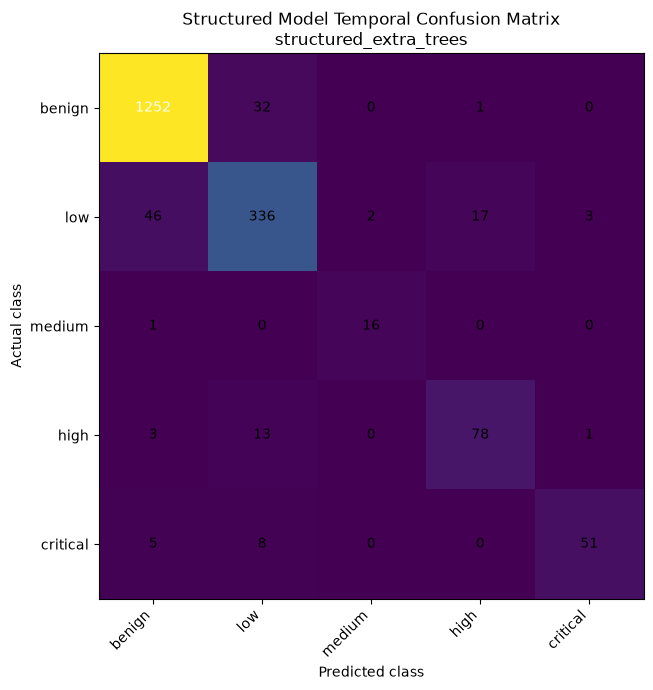

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\figures\best_structured_confusion_matrix.png


In [34]:
plt.figure(figsize=(9, 7))

plt.imshow(
    best_structured_confusion_matrix,
    interpolation="nearest",
)

plt.title(
    "Structured Model Temporal Confusion Matrix\n"
    f"{best_structured_name}"
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.xticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
)

maximum_matrix_value = (
    best_structured_confusion_matrix.max()
    if best_structured_confusion_matrix.size
    else 0
)

matrix_text_threshold = (
    maximum_matrix_value / 2.0
)

for row_index in range(
    best_structured_confusion_matrix.shape[0]
):
    for column_index in range(
        best_structured_confusion_matrix.shape[1]
    ):
        value = (
            best_structured_confusion_matrix[
                row_index,
                column_index,
            ]
        )

        plt.text(
            column_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            color=(
                "white"
                if value
                > matrix_text_threshold
                else "black"
            ),
        )

plt.tight_layout()

structured_confusion_figure_path = (
    FIGURES_DIR
    / "best_structured_confusion_matrix.png"
)

plt.savefig(
    structured_confusion_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    structured_confusion_figure_path,
)

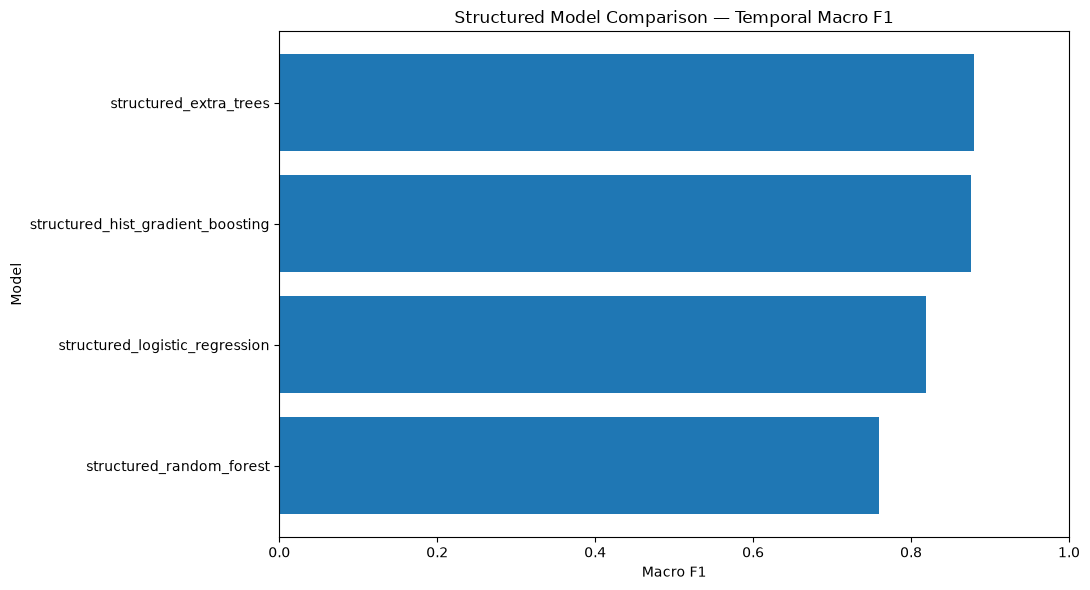

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\figures\structured_macro_f1_comparison.png


In [36]:
structured_plot_data = (
    structured_results
    .sort_values(
        "macro_f1",
        ascending=True,
    )
)

plt.figure(figsize=(11, 6))

plt.barh(
    structured_plot_data["model"],
    structured_plot_data["macro_f1"],
)

plt.title(
    "Structured Model Comparison — Temporal Macro F1"
)

plt.xlabel("Macro F1")
plt.ylabel("Model")

plt.xlim(
    0,
    max(
        1.0,
        structured_plot_data[
            "macro_f1"
        ].max()
        * 1.10,
    ),
)

plt.tight_layout()

structured_comparison_figure_path = (
    FIGURES_DIR
    / "structured_macro_f1_comparison.png"
)

plt.savefig(
    structured_comparison_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    structured_comparison_figure_path,
)

In [37]:
best_structured_prediction_output = (
    temporal_development_data[
        [
            "diff_id",
            "repository",
            "commit_hash",
            "commit_author_date",
            "file_path",
            "configuration_type",
            "parser_mode",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "training_target",
            "sample_weight",
        ]
    ]
    .copy()
)

best_structured_prediction_output[
    "predicted_label"
] = best_structured_predictions

best_structured_prediction_output[
    "prediction_correct"
] = (
    best_structured_prediction_output[
        "training_target"
    ]
    == best_structured_prediction_output[
        "predicted_label"
    ]
)

best_structured_probability_matrix = (
    structured_probabilities[
        best_structured_name
    ]
)

if (
    best_structured_probability_matrix
    is not None
):
    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        best_structured_prediction_output[
            f"probability_{class_name}"
        ] = (
            best_structured_probability_matrix[
                :,
                class_index,
            ]
        )

    best_structured_prediction_output[
        "maximum_probability"
    ] = (
        best_structured_probability_matrix.max(
            axis=1
        )
    )

    sorted_probabilities = np.sort(
        best_structured_probability_matrix,
        axis=1,
    )

    best_structured_prediction_output[
        "probability_margin"
    ] = (
        sorted_probabilities[
            :,
            -1,
        ]
        - sorted_probabilities[
            :,
            -2,
        ]
    )

print(
    "Prediction rows:",
    f"{len(best_structured_prediction_output):,}",
)

display(
    best_structured_prediction_output.head()
)

Prediction rows: 1,865


,diff_id,repository,commit_hash,commit_author_date,file_path,configuration_type,parser_mode,operation,field_path,old_value,...,sample_weight,predicted_label,prediction_correct,probability_benign,probability_low,probability_medium,probability_high,probability_critical,maximum_probability,probability_margin
0,5312313a6a8671e134373e039b11e7051bf292e43aa616...,kube_prometheus,760b786b29edb4aa917e87746cb9e2cab9cf3066,2025-09-15T10:37:32+02:00,manifests/setup/0servicemonitorCustomResourceD...,yaml,structured,modified,$.spec.versions[0].schema.openAPIV3Schema.prop...,"When true, the pods which are not running (e.g...",...,1.255671,high,False,0.062849,0.226243,1.000000e-12,7.109084e-01,1.000000e-12,0.710908,0.484665
1,f56009fd0c56e99cbefde963be7533ee48cb222ea2db1c...,microservices_demo,18f3b732934abd656dc013bac7327a95c762b21c,2025-11-26T11:57:37-05:00,release/kubernetes-manifests.yaml,kubernetes,structured,modified,$.documents[19].spec.template.spec.containers[...,7070,...,1.255671,low,True,0.002853,0.992147,1.000000e-12,2.500000e-03,2.500000e-03,0.992147,0.989294
2,4363d09488d6d823688af9d432a3ca91ca73de992902ef...,microservices_demo,12b18767d5d7505aef4fe88b9ed3c9adbd4fd335,2025-07-24T19:38:03-04:00,src/currencyservice/package-lock.json,json,structured,added,$.packages.node_modules/call-bind-apply-helper...,NaN,...,9.600000,low,False,0.000047,0.724090,1.000000e-12,2.758634e-01,1.000000e-12,0.724090,0.448227
3,2ecd8afa3913089561843c31d64520e2dc94eb220bda33...,microservices_demo,7cfba453a014340f66c4b4963adfc0718858fd91,2025-05-29T21:56:03+03:00,helm-chart/values.yaml,helm,structured,modified,$.cartService.resources.limits.memory,128Mi,...,1.255671,low,True,0.316602,0.666751,5.000000e-03,9.146854e-03,2.500000e-03,0.666751,0.350150
4,d2bb2e68d4656d2a8873d6838d9d2616ea03d8d6d3cba2...,microservices_demo,abf56c68cee6d201e2b7f00e5848d49398a12de7,2025-10-14T15:38:39+01:00,src/paymentservice/package-lock.json,json,structured,deleted,$.dependencies.is-core-module.version,2.13.0,...,0.206497,benign,True,0.936222,0.019773,1.000000e-12,1.000000e-12,4.400569e-02,0.936222,0.892216


In [38]:
critical_mask = (
    best_structured_prediction_output[
        "training_target"
    ].eq("critical")
)

critical_false_negative_mask = (
    critical_mask
    &
    ~best_structured_prediction_output[
        "predicted_label"
    ].eq("critical")
)

structured_critical_false_negatives = (
    best_structured_prediction_output[
        critical_false_negative_mask
    ]
    .copy()
)

actual_high_critical = (
    best_structured_prediction_output[
        "training_target"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

predicted_high_critical = (
    best_structured_prediction_output[
        "predicted_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

structured_high_critical_false_negatives = (
    best_structured_prediction_output[
        actual_high_critical
        & ~predicted_high_critical
    ]
    .copy()
)

structured_high_critical_false_positives = (
    best_structured_prediction_output[
        ~actual_high_critical
        & predicted_high_critical
    ]
    .copy()
)

print(
    "Critical temporal-development records:",
    f"{int(critical_mask.sum()):,}",
)

print(
    "Critical false negatives:",
    f"{len(structured_critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(structured_high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(structured_high_critical_false_positives):,}",
)

display(
    structured_critical_false_negatives[
        [
            "repository",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "predicted_label",
        ]
    ].head(20)
)

Critical temporal-development records: 64
Critical false negatives: 13
High/critical false negatives: 29
High/critical false positives: 21


,repository,configuration_type,operation,field_path,old_value,new_value,predicted_label
56,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.prop...,1,NaN,low
101,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.prop...,1,NaN,low
139,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.prop...,1,NaN,low
150,microservices_demo,json,deleted,$.packages.node_modules/google-auth-library/no...,https://registry.npmjs.org/gaxios/-/gaxios-5.1...,NaN,low
240,microservices_demo,json,deleted,$.dependencies.google-auth-library.dependencie...,https://registry.npmjs.org/gcp-metadata/-/gcp-...,NaN,low
587,kube_prometheus,yaml,added,$.spec.versions[0].schema.openAPIV3Schema.prop...,NaN,admin,benign
759,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.prop...,cert,NaN,benign
1407,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.prop...,1,NaN,low
1410,microservices_demo,json,deleted,$.packages.node_modules/google-auth-library/no...,https://registry.npmjs.org/gcp-metadata/-/gcp-...,NaN,low
1478,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.prop...,key,NaN,benign


In [39]:
structured_misclassified_records = (
    best_structured_prediction_output[
        ~best_structured_prediction_output[
            "prediction_correct"
        ]
    ]
    .copy()
)

structured_error_transitions = (
    structured_misclassified_records
    .groupby(
        [
            "training_target",
            "predicted_label",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
    .sort_values(
        "records",
        ascending=False,
    )
)

print(
    "Misclassified records:",
    f"{len(structured_misclassified_records):,}",
)

display(
    structured_error_transitions.head(30)
)

structured_error_transitions.to_csv(
    TABLES_DIR
    / "structured_error_transitions.csv",
    index=False,
)

Misclassified records: 132


,training_target,predicted_label,records
7,low,benign,46
1,benign,low,32
9,low,high,17
6,high,low,13
3,critical,low,8
2,critical,benign,5
8,low,critical,3
4,high,benign,3
10,low,medium,2
0,benign,high,1


In [40]:
configuration_metric_records = []

for (
    configuration_type,
    configuration_data,
) in best_structured_prediction_output.groupby(
    "configuration_type"
):
    if len(configuration_data) < (
        STRUCTURED_SETTINGS[
            "minimum_configuration_group_size"
        ]
    ):
        continue

    configuration_metric_records.append(
        {
            "configuration_type":
                configuration_type,

            "records":
                len(configuration_data),

            "classes_present":
                configuration_data[
                    "training_target"
                ].nunique(),

            "accuracy": float(
                accuracy_score(
                    configuration_data[
                        "training_target"
                    ],
                    configuration_data[
                        "predicted_label"
                    ],
                )
            ),

            "balanced_accuracy": float(
                balanced_accuracy_score(
                    configuration_data[
                        "training_target"
                    ],
                    configuration_data[
                        "predicted_label"
                    ],
                )
            ),

            "macro_f1": float(
                f1_score(
                    configuration_data[
                        "training_target"
                    ],
                    configuration_data[
                        "predicted_label"
                    ],
                    labels=CLASS_ORDER,
                    average="macro",
                    zero_division=0,
                )
            ),
        }
    )

structured_configuration_metrics = (
    pd.DataFrame(
        configuration_metric_records
    )
)

if not structured_configuration_metrics.empty:
    structured_configuration_metrics = (
        structured_configuration_metrics
        .sort_values(
            [
                "records",
                "macro_f1",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )

display(
    structured_configuration_metrics.head(30)
)

structured_configuration_metrics.to_csv(
    TABLES_DIR
    / "structured_configuration_type_metrics.csv",
    index=False,
)

C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,configuration_type,records,classes_present,accuracy,balanced_accuracy,macro_f1
2,json,514,4,0.968872,0.707466,0.570909
3,kubernetes,488,5,0.975410,0.981332,0.974844
6,yaml,485,5,0.868041,0.498625,0.485777
5,terraform,247,4,0.846154,0.809424,0.603923
4,kustomize,101,1,1.000000,1.000000,0.200000
1,helm,12,2,1.000000,1.000000,0.400000
0,configuration,11,1,1.000000,1.000000,0.200000


In [41]:
parser_metric_records = []

for (
    parser_mode,
    parser_data,
) in best_structured_prediction_output.groupby(
    "parser_mode"
):
    parser_metric_records.append(
        {
            "parser_mode":
                parser_mode,

            "records":
                len(parser_data),

            "accuracy": float(
                accuracy_score(
                    parser_data[
                        "training_target"
                    ],
                    parser_data[
                        "predicted_label"
                    ],
                )
            ),

            "balanced_accuracy": float(
                balanced_accuracy_score(
                    parser_data[
                        "training_target"
                    ],
                    parser_data[
                        "predicted_label"
                    ],
                )
            ),

            "macro_f1": float(
                f1_score(
                    parser_data[
                        "training_target"
                    ],
                    parser_data[
                        "predicted_label"
                    ],
                    labels=CLASS_ORDER,
                    average="macro",
                    zero_division=0,
                )
            ),
        }
    )

structured_parser_metrics = (
    pd.DataFrame(
        parser_metric_records
    )
)

display(
    structured_parser_metrics
)

structured_parser_metrics.to_csv(
    TABLES_DIR
    / "structured_parser_mode_metrics.csv",
    index=False,
)

,parser_mode,records,accuracy,balanced_accuracy,macro_f1
0,structured,1865,0.929223,0.873021,0.880329


In [42]:
print(
    "Calculating permutation importance for:",
    best_structured_name,
)

permutation_start = time.perf_counter()

permutation_result = (
    permutation_importance(
        estimator=best_structured_model,
        X=X_development_structured,
        y=y_development,
        scoring="f1_macro",
        n_repeats=(
            STRUCTURED_SETTINGS[
                "permutation_importance_repeats"
            ]
        ),
        random_state=(
            STRUCTURED_SETTINGS[
                "random_seed"
            ]
        ),
        n_jobs=-1,
    )
)

permutation_seconds = (
    time.perf_counter()
    - permutation_start
)

structured_permutation_importance = (
    pd.DataFrame(
        {
            "feature":
                X_development_structured.columns,

            "importance_mean":
                permutation_result.importances_mean,

            "importance_std":
                permutation_result.importances_std,
        }
    )
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

structured_permutation_importance.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            structured_permutation_importance
        ) + 1,
    ),
)

print(
    "Permutation-importance seconds:",
    f"{permutation_seconds:.2f}",
)

display(
    structured_permutation_importance.head(
        STRUCTURED_SETTINGS[
            "permutation_importance_top_n"
        ]
    )
)

structured_permutation_importance.to_csv(
    TABLES_DIR
    / "structured_permutation_importance.csv",
    index=False,
)

Calculating permutation importance for: structured_extra_trees
Permutation-importance seconds: 84.39


,rank,feature,importance_mean,importance_std
0,1,field_security_keyword_count,0.062716,0.004312
1,2,field_leaf,0.051021,0.002625
2,3,field_network_keyword_count,0.014338,0.001689
3,4,new_contains_wildcard,0.011497,0.000549
4,5,file_extension,0.007878,0.003300
5,6,new_contains_url,0.007662,0.002389
6,7,new_contains_ipv4,0.005391,0.000000
7,8,new_value_type,0.004418,0.004154
8,9,configuration_type,0.004401,0.001934
9,10,new_contains_cidr,0.004057,0.000000


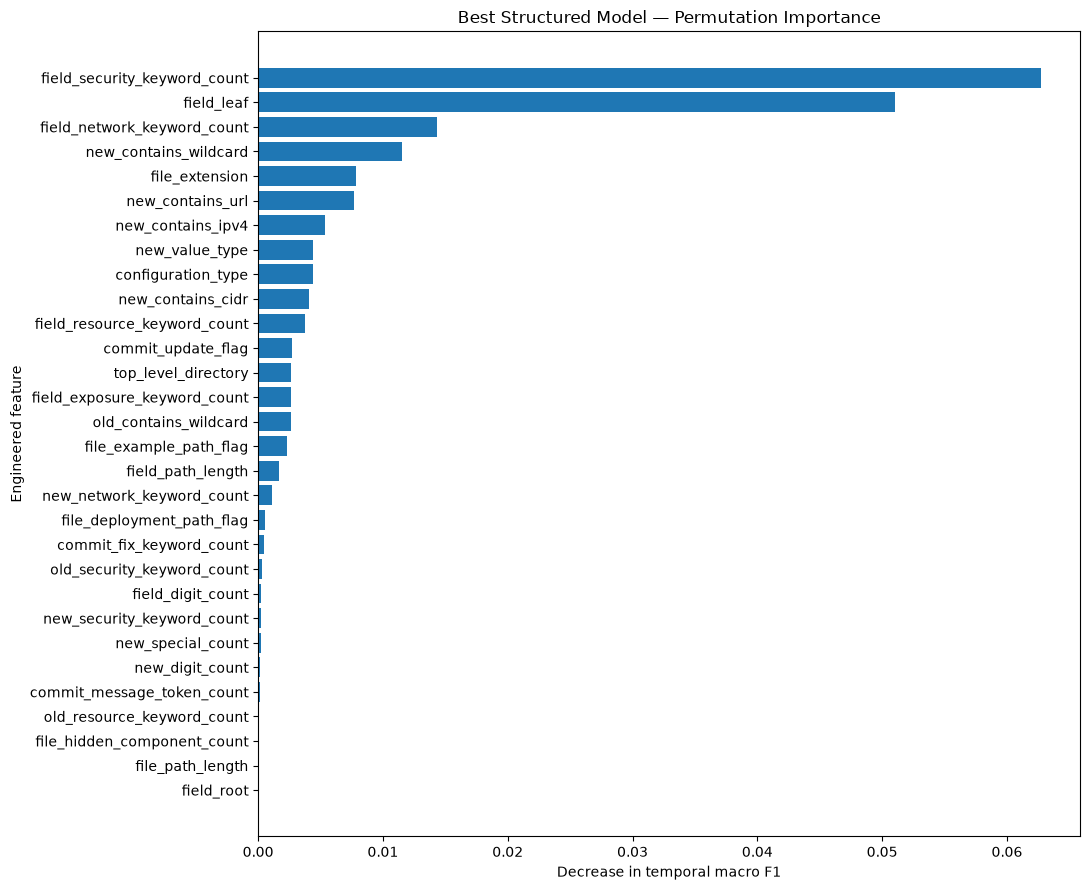

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\figures\structured_permutation_importance.png


In [43]:
top_permutation_features = (
    structured_permutation_importance
    .head(
        STRUCTURED_SETTINGS[
            "permutation_importance_top_n"
        ]
    )
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(figsize=(11, 9))

plt.barh(
    top_permutation_features[
        "feature"
    ],
    top_permutation_features[
        "importance_mean"
    ],
)

plt.title(
    "Best Structured Model — Permutation Importance"
)

plt.xlabel(
    "Decrease in temporal macro F1"
)

plt.ylabel("Engineered feature")

plt.tight_layout()

permutation_figure_path = (
    FIGURES_DIR
    / "structured_permutation_importance.png"
)

plt.savefig(
    permutation_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    permutation_figure_path,
)

In [44]:
saved_structured_model_paths = {}

for (
    model_name,
    trained_model,
) in trained_structured_models.items():
    model_path = (
        MODELS_DIR
        / f"{model_name}.joblib"
    )

    joblib.dump(
        trained_model,
        model_path,
        compress=3,
    )

    saved_structured_model_paths[
        model_name
    ] = str(model_path)

    print(
        f"{model_name:<40}",
        "->",
        model_path.name,
    )

best_structured_model_path = (
    MODELS_DIR
    / "best_structured_model.joblib"
)

joblib.dump(
    best_structured_model,
    best_structured_model_path,
    compress=3,
)

print(
    "\nBest structured model saved:",
    best_structured_model_path,
)

structured_logistic_regression           -> structured_logistic_regression.joblib
structured_random_forest                 -> structured_random_forest.joblib
structured_extra_trees                   -> structured_extra_trees.joblib
structured_hist_gradient_boosting        -> structured_hist_gradient_boosting.joblib

Best structured model saved: C:\Users\Lenovo\Desktop\DriftGuard\models\structured\best_structured_model.joblib


In [45]:
structured_results_path = (
    TABLES_DIR
    / "structured_model_comparison.csv"
)

structured_results.to_csv(
    structured_results_path,
    index=False,
)

overall_comparison_path = (
    TABLES_DIR
    / "baseline_vs_structured_comparison.csv"
)

overall_temporal_comparison.to_csv(
    overall_comparison_path,
    index=False,
)

prediction_output_path = (
    PREDICTIONS_DIR
    / "best_structured_temporal_predictions.csv.gz"
)

best_structured_prediction_output.to_csv(
    prediction_output_path,
    index=False,
    compression="gzip",
)

critical_false_negative_path = (
    PREDICTIONS_DIR
    / "structured_critical_false_negatives.csv.gz"
)

structured_critical_false_negatives.to_csv(
    critical_false_negative_path,
    index=False,
    compression="gzip",
)

high_critical_false_negative_path = (
    PREDICTIONS_DIR
    / "structured_high_critical_false_negatives.csv.gz"
)

structured_high_critical_false_negatives.to_csv(
    high_critical_false_negative_path,
    index=False,
    compression="gzip",
)

training_errors_path = (
    OUTPUTS_DIR
    / "structured_training_errors.json"
)

with training_errors_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        structured_training_errors,
        file,
        indent=2,
    )

print(
    "Saved model comparison:",
    structured_results_path,
)

print(
    "Saved baseline comparison:",
    overall_comparison_path,
)

print(
    "Saved predictions:",
    prediction_output_path,
)

print(
    "Saved training errors:",
    training_errors_path,
)

Saved model comparison: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\tables\structured_model_comparison.csv
Saved baseline comparison: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\tables\baseline_vs_structured_comparison.csv
Saved predictions: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\predictions\best_structured_temporal_predictions.csv.gz
Saved training errors: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\structured_training_errors.json


In [47]:
training_feature_columns = set(
    X_train_structured.columns
)

forbidden_engineered_overlap = (
    training_feature_columns
    & FORBIDDEN_FEATURE_COLUMNS
)

structured_integrity_checks = {
    "Training data is not empty":
        len(
            model_training_data
        ) > 0,

    "Development data is not empty":
        len(
            temporal_development_data
        ) > 0,

    "Training and development commits are disjoint":
        len(
            overlapping_commit_keys
        ) == 0,

    "All five training classes exist":
        set(
            CLASS_ORDER
        ).issubset(
            set(
                y_train
            )
        ),

    "All five development classes exist":
        set(
            CLASS_ORDER
        ).issubset(
            set(
                y_development
            )
        ),

    "No forbidden feature is present":
        len(
            forbidden_engineered_overlap
        ) == 0,

    "Training and development feature schemas match":
        list(
            X_train_structured.columns
        )
        == list(
            X_development_structured.columns
        ),

    "At least one structured model succeeded":
        len(
            trained_structured_models
        ) > 0,

    "Predictions match development row count":
        len(
            best_structured_prediction_output
        )
        == len(
            temporal_development_data
        ),

    "Predictions contain valid classes":
        best_structured_prediction_output[
            "predicted_label"
        ].isin(
            CLASS_ORDER
        ).all(),

    "Macro F1 is finite":
        np.isfinite(
            best_structured_row[
                "macro_f1"
            ]
        ),

    "Critical recall is finite":
        np.isfinite(
            best_structured_row[
                "critical_recall"
            ]
        ),

    "Best model file exists":
        best_structured_model_path.exists(),

    "Metrics output exists":
        structured_results_path.exists(),

    "Prediction output exists":
        prediction_output_path.exists(),

    "Feature schema exists":
        feature_schema_path.exists(),

    "Permutation importance was generated":
        not structured_permutation_importance.empty,
}

print("Structured-model integrity checks:\n")

for (
    check_name,
    passed,
) in structured_integrity_checks.items():
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_structured_checks = [
    check_name
    for (
        check_name,
        passed,
    ) in structured_integrity_checks.items()
    if not bool(passed)
]

print(
    "\nFailed integrity checks:",
    len(
        failed_structured_checks
    ),
)

Structured-model integrity checks:

PASSED   | Training data is not empty
PASSED   | Development data is not empty
PASSED   | Training and development commits are disjoint
PASSED   | All five training classes exist
PASSED   | All five development classes exist
PASSED   | No forbidden feature is present
PASSED   | Training and development feature schemas match
PASSED   | At least one structured model succeeded
PASSED   | Predictions match development row count
PASSED   | Predictions contain valid classes
PASSED   | Macro F1 is finite
PASSED   | Critical recall is finite
PASSED   | Best model file exists
PASSED   | Metrics output exists
PASSED   | Prediction output exists
PASSED   | Feature schema exists
PASSED   | Permutation importance was generated

Failed integrity checks: 0


In [48]:
def convert_json_value(value):
    if pd.isna(value):
        return None

    if isinstance(
        value,
        (
            np.integer,
            int,
        ),
    ):
        return int(value)

    if isinstance(
        value,
        (
            np.floating,
            float,
        ),
    ):
        return float(value)

    if isinstance(
        value,
        np.bool_,
    ):
        return bool(value)

    return value


best_structured_metrics = {
    key: convert_json_value(value)
    for key, value
    in best_structured_row.to_dict().items()
}

structured_summary = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "model_training_records":
        int(
            len(
                model_training_data
            )
        ),

    "temporal_development_records":
        int(
            len(
                temporal_development_data
            )
        ),

    "model_training_commits":
        int(
            len(
                training_commit_keys
            )
        ),

    "temporal_development_commits":
        int(
            len(
                development_commit_keys
            )
        ),

    "raw_allowed_columns":
        RAW_ALLOWED_COLUMNS,

    "engineered_feature_count":
        int(
            len(
                X_train_structured.columns
            )
        ),

    "categorical_feature_count":
        int(
            len(
                CATEGORICAL_FEATURE_COLUMNS
            )
        ),

    "numeric_feature_count":
        int(
            len(
                NUMERIC_FEATURE_COLUMNS
            )
        ),

    "successful_models":
        sorted(
            trained_structured_models.keys()
        ),

    "failed_models":
        structured_training_errors,

    "best_structured_model":
        best_structured_name,

    "best_structured_metrics":
        best_structured_metrics,

    "best_structured_model_path":
        str(
            best_structured_model_path
        ),

    "critical_false_negatives":
        int(
            len(
                structured_critical_false_negatives
            )
        ),

    "high_critical_false_negatives":
        int(
            len(
                structured_high_critical_false_negatives
            )
        ),

    "high_critical_false_positives":
        int(
            len(
                structured_high_critical_false_positives
            )
        ),

    "failed_integrity_checks":
        failed_structured_checks,

    "all_integrity_checks_passed":
        len(
            failed_structured_checks
        ) == 0,
}

if best_baseline_row is not None:
    structured_summary[
        "baseline_comparison"
    ] = {
        "baseline_model":
            str(
                best_baseline_row[
                    "model"
                ]
            ),

        "baseline_macro_f1":
            float(
                best_baseline_row[
                    "macro_f1"
                ]
            ),

        "structured_minus_baseline_macro_f1":
            float(
                macro_f1_difference
            ),

        "baseline_critical_recall":
            float(
                best_baseline_row[
                    "critical_recall"
                ]
            ),

        "structured_minus_baseline_critical_recall":
            float(
                critical_recall_difference
            ),
    }

structured_summary_path = (
    OUTPUTS_DIR
    / "structured_training_summary.json"
)

with structured_summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        structured_summary,
        file,
        indent=2,
    )

print(
    "Saved structured summary:",
    structured_summary_path,
)

Saved structured summary: C:\Users\Lenovo\Desktop\DriftGuard\outputs\structured_models\structured_training_summary.json


In [49]:
print("=" * 72)
print("NOTEBOOK 08 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. DATASET USAGE")
print("-" * 72)

print(
    "Model-training records       :",
    f"{len(model_training_data):,}",
)

print(
    "Temporal-development records :",
    f"{len(temporal_development_data):,}",
)

print(
    "Model-training commits       :",
    f"{len(training_commit_keys):,}",
)

print(
    "Temporal-development commits :",
    f"{len(development_commit_keys):,}",
)

print(
    "Overlapping commits          :",
    f"{len(overlapping_commit_keys):,}",
)

print("\n2. STRUCTURED FEATURES")
print("-" * 72)

print(
    "Engineered feature columns:",
    f"{len(X_train_structured.columns):,}",
)

print(
    "Categorical features       :",
    f"{len(CATEGORICAL_FEATURE_COLUMNS):,}",
)

print(
    "Numeric features           :",
    f"{len(NUMERIC_FEATURE_COLUMNS):,}",
)

print(
    "Constant features removed :",
    f"{len(constant_features):,}",
)

print("\n3. STRUCTURED MODEL RANKING")
print("-" * 72)

display(
    structured_results[
        [
            "rank",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "log_loss",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
        ]
    ]
)

print("\n4. BEST STRUCTURED MODEL")
print("-" * 72)

print(
    "Best model             :",
    best_structured_name,
)

print(
    "Macro F1               :",
    f"{best_structured_row['macro_f1']:.4f}",
)

print(
    "Balanced accuracy      :",
    f"{best_structured_row['balanced_accuracy']:.4f}",
)

print(
    "Macro PR-AUC           :",
    f"{best_structured_row['macro_pr_auc']:.4f}",
)

print(
    "Critical precision     :",
    f"{best_structured_row['critical_precision']:.4f}",
)

print(
    "Critical recall        :",
    f"{best_structured_row['critical_recall']:.4f}",
)

print(
    "High/critical precision:",
    f"{best_structured_row['high_critical_precision']:.4f}",
)

print(
    "High/critical recall   :",
    f"{best_structured_row['high_critical_recall']:.4f}",
)

print("\n5. PER-CLASS RESULTS")
print("-" * 72)

display(
    best_structured_per_class[
        [
            "class",
            "support",
            "precision",
            "recall",
            "f1",
            "average_precision",
        ]
    ]
)

print("\n6. COMPARISON WITH TEXT BASELINE")
print("-" * 72)

display(
    overall_temporal_comparison
)

if best_baseline_row is not None:
    print(
        "Structured minus baseline macro F1:",
        f"{macro_f1_difference:+.4f}",
    )

    print(
        "Structured minus baseline critical recall:",
        f"{critical_recall_difference:+.4f}",
    )

print("\n7. SAFETY-CRITICAL ERRORS")
print("-" * 72)

print(
    "Critical false negatives:",
    f"{len(structured_critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(structured_high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(structured_high_critical_false_positives):,}",
)

print("\n8. TOP PERMUTATION FEATURES")
print("-" * 72)

display(
    structured_permutation_importance[
        [
            "rank",
            "feature",
            "importance_mean",
            "importance_std",
        ]
    ].head(15)
)

print("\n9. TRAINING FAILURES")
print("-" * 72)

if structured_training_errors:
    for (
        model_name,
        error_details,
    ) in structured_training_errors.items():
        print(
            model_name,
            "->",
            error_details[
                "error_type"
            ],
            ":",
            error_details[
                "error_message"
            ],
        )
else:
    print(
        "No structured models failed."
    )

print("\n10. FAILED INTEGRITY CHECKS")
print("-" * 72)

if failed_structured_checks:
    for index, check_name in enumerate(
        failed_structured_checks,
        start=1,
    ):
        print(
            f"{index}. {check_name}"
        )
else:
    print(
        "No failed integrity checks."
    )

    print(
        "All structured-model integrity checks passed."
    )

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 08 — REQUIRED RESULTS

1. DATASET USAGE
------------------------------------------------------------------------
Model-training records       : 7,711
Temporal-development records : 1,865
Model-training commits       : 1,058
Temporal-development commits : 266
Overlapping commits          : 0

2. STRUCTURED FEATURES
------------------------------------------------------------------------
Engineered feature columns: 80
Categorical features       : 11
Numeric features           : 69
Constant features removed : 3

3. STRUCTURED MODEL RANKING
------------------------------------------------------------------------


,rank,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1
0,1,structured_extra_trees,0.929223,0.873021,0.880329,0.928537,0.943107,4.546531,0.927273,0.796875,0.857143,0.860927,0.817610,0.838710
1,2,structured_hist_gradient_boosting,0.924933,0.883145,0.876010,0.926040,0.938938,2.173274,0.791045,0.828125,0.809160,0.783626,0.842767,0.812121
2,3,structured_logistic_regression,0.890617,0.870153,0.818286,0.895532,0.830488,3.200968,0.663043,0.953125,0.782051,0.646288,0.930818,0.762887
3,4,structured_random_forest,0.851475,0.889641,0.758824,0.861217,0.925477,2.478717,0.895522,0.937500,0.916031,0.628821,0.905660,0.742268



4. BEST STRUCTURED MODEL
------------------------------------------------------------------------
Best model             : structured_extra_trees
Macro F1               : 0.8803
Balanced accuracy      : 0.8730
Macro PR-AUC           : 0.9431
Critical precision     : 0.9273
Critical recall        : 0.7969
High/critical precision: 0.8609
High/critical recall   : 0.8176

5. PER-CLASS RESULTS
------------------------------------------------------------------------


,class,support,precision,recall,f1,average_precision
10,benign,1285,0.957919,0.974319,0.966049,0.992142
11,low,404,0.863753,0.831683,0.847415,0.935608
12,medium,17,0.888889,0.941176,0.914286,0.957049
13,high,95,0.812500,0.821053,0.816754,0.893969
14,critical,64,0.927273,0.796875,0.857143,0.936766



6. COMPARISON WITH TEXT BASELINE
------------------------------------------------------------------------


,model_family,model,macro_f1,balanced_accuracy,macro_pr_auc,critical_precision,critical_recall,high_critical_precision,high_critical_recall
0,text_baseline,hybrid_linear_svm,0.899128,0.894573,0.916507,0.866667,0.812500,0.924658,0.849057
1,structured,structured_extra_trees,0.880329,0.873021,0.943107,0.927273,0.796875,0.860927,0.817610


Structured minus baseline macro F1: -0.0188
Structured minus baseline critical recall: -0.0156

7. SAFETY-CRITICAL ERRORS
------------------------------------------------------------------------
Critical false negatives: 13
High/critical false negatives: 29
High/critical false positives: 21

8. TOP PERMUTATION FEATURES
------------------------------------------------------------------------


,rank,feature,importance_mean,importance_std
0,1,field_security_keyword_count,0.062716,0.004312
1,2,field_leaf,0.051021,0.002625
2,3,field_network_keyword_count,0.014338,0.001689
3,4,new_contains_wildcard,0.011497,0.000549
4,5,file_extension,0.007878,0.003300
5,6,new_contains_url,0.007662,0.002389
6,7,new_contains_ipv4,0.005391,0.000000
7,8,new_value_type,0.004418,0.004154
8,9,configuration_type,0.004401,0.001934
9,10,new_contains_cidr,0.004057,0.000000



9. TRAINING FAILURES
------------------------------------------------------------------------
No structured models failed.

10. FAILED INTEGRITY CHECKS
------------------------------------------------------------------------
No failed integrity checks.
All structured-model integrity checks passed.

REQUIRED RESULTS GENERATED


In [51]:
print("=" * 72)
print("NOTEBOOK 08 COMPLETED")
print("=" * 72)

print(
    "Structured models attempted:",
    len(
        STRUCTURED_MODELS
    ),
)

print(
    "Successful models:",
    len(
        trained_structured_models
    ),
)

print(
    "Failed models:",
    len(
        structured_training_errors
    ),
)

print(
    "Engineered features:",
    len(
        X_train_structured.columns
    ),
)

print(
    "Best structured model:",
    best_structured_name,
)

print(
    "Best structured macro F1:",
    f"{best_structured_row['macro_f1']:.4f}",
)

print(
    "Best structured critical recall:",
    f"{best_structured_row['critical_recall']:.4f}",
)

print(
    "Best structured high/critical recall:",
    f"{best_structured_row['high_critical_recall']:.4f}",
)

print(
    "Critical false negatives:",
    f"{len(structured_critical_false_negatives):,}",
)

if best_baseline_row is not None:
    print(
        "Text baseline macro F1:",
        f"{best_baseline_row['macro_f1']:.4f}",
    )

    print(
        "Structured macro F1 difference:",
        f"{macro_f1_difference:+.4f}",
    )

print(
    "Best model saved to:",
    best_structured_model_path,
)

print("\nImportant:")
print("- Structured features were generated only from raw change content.")
print("- Repository identity and commit hashes were excluded.")
print("- Weak-label rules and explanations were excluded.")
print("- Validation and test repositories were not loaded for training.")
print("- Temporal development remained commit-disjoint.")
print("- The text and structured models may later be combined in the hybrid engine.")

print("\nNext notebook:")
print("09_train_nlp_transformer.ipynb")

NOTEBOOK 08 COMPLETED
Structured models attempted: 4
Successful models: 4
Failed models: 0
Engineered features: 80
Best structured model: structured_extra_trees
Best structured macro F1: 0.8803
Best structured critical recall: 0.7969
Best structured high/critical recall: 0.8176
Critical false negatives: 13
Text baseline macro F1: 0.8991
Structured macro F1 difference: -0.0188
Best model saved to: C:\Users\Lenovo\Desktop\DriftGuard\models\structured\best_structured_model.joblib

Important:
- Structured features were generated only from raw change content.
- Repository identity and commit hashes were excluded.
- Weak-label rules and explanations were excluded.
- Validation and test repositories were not loaded for training.
- Temporal development remained commit-disjoint.
- The text and structured models may later be combined in the hybrid engine.

Next notebook:
09_train_nlp_transformer.ipynb
